In [2]:
!pip install gensim matplotlib

In [3]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [16]:
# 2. BASİT BİR DERLEM (CORPUS) TANIMLAMA
derlem = [
    ["bütçe_dostu_araç", "uygun_fiyatlı", "verimli", "temel_özellikler"],
    ["lüks_araç", "pahalı", "güçlü", "premium_özellikler"],
    ["bütçe_dostu_araç", "kompakt", "yakıt_tasarruflu", "küçük"],
    ["lüks_araç", "geniş", "yüksek_performans", "lüks"],
    ["bütçe_dostu_araç", "güvenilir", "düşük_maliyet", "ekonomik"],
    ["lüks_araç", "prestijli", "gelişmiş", "özel"]
]

In [17]:
# 3. WORD2VEC MODELİNİ VARSAYILAN PARAMETRELERLE EĞİTME
model = Word2Vec(
    sentences=derlem,      # Girdi derlemi (kelimelere ayrılmış cümleler listesi)
    vector_size=10,        # Her kelime için oluşturulacak vektörün boyutu
    window=3,              # Hedef kelime ile bağlam kelimesi arasındaki maksimum mesafe
    min_count=1,           # Frekansı bundan az olan kelimeleri hesaba katma
    sg=1,                  # 1: Skip-gram mimarisi, 0: CBOW mimarisi
    epochs=10              # Veri seti üzerinde kaç tam tur eğitim yapılacağı
)

In [18]:
# Örnek vektörü inceleme
print("'bütçe_dostu_araç' kelimesinin vektör temsili:\n", model.wv['bütçe_dostu_araç'])

'bütçe_dostu_araç' kelimesinin vektör temsili:
 [ 0.07377523 -0.01531201 -0.04542411  0.0655497  -0.04852345 -0.01816111
  0.02884895  0.00990199 -0.08290677 -0.09446687]


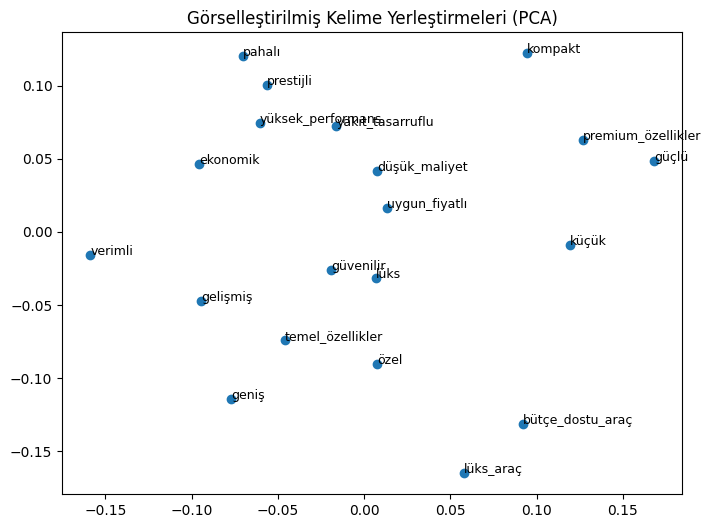

In [35]:
# 4. PCA KULLANARAK BOYUT İNDİRGEME VE GÖRSELLEŞTİRME
kelime_vektorleri = model.wv
kelimeler = list(kelime_vektorleri.index_to_key)

# Çok boyutlu vektörleri PCA ile 2 boyuta düşürüyoruz
X = kelime_vektorleri[kelimeler]
pca = PCA(n_components=2)
sonuc_pca = pca.fit_transform(X)

# PCA sonuçlarını çizdirme
plt.figure(figsize=(8,6))
plt.scatter(sonuc_pca[:, 0], sonuc_pca[:, 1], marker='o')
for i, kelime in enumerate(kelimeler):
    plt.annotate(kelime, xy=(sonuc_pca[i, 0], sonuc_pca[i, 1]), fontsize=9)
plt.title("Görselleştirilmiş Kelime Yerleştirmeleri (PCA)")
plt.show()

In [20]:
# 5. MODELİ GELİŞTİRME VE t-SNE İLE YENİDEN GÖRSELLEŞTİRME
# Parametreleri iyileştirerek (daha büyük vektör, CBOW) modeli yeniden eğitiyoruz
gelismis_model = Word2Vec(
    sentences=derlem,
    vector_size=50,        # Daha iyi temsil için artırılmış vektör boyutu
    window=5,              # Daha büyük bağlam penceresi
    min_count=1,
    sg=0,                  # Daha iyi kelime eşleşmesi için CBOW (Continuous Bag of Words) kullanımı
    epochs=50              # Vektörlere ince ayar için daha fazla eğitim (epoch)
)

In [21]:
# Yeni modelden vektörleri alma
yeni_kelime_vektorleri = gelismis_model.wv
yeni_kelimeler = list(yeni_kelime_vektorleri.index_to_key)
X_yeni = yeni_kelime_vektorleri[yeni_kelimeler]

In [22]:
# t-SNE kullanarak boyutları küçültme
tsne = TSNE(n_components=2, perplexity=3, random_state=42)
sonuc_tsne = tsne.fit_transform(X_yeni)

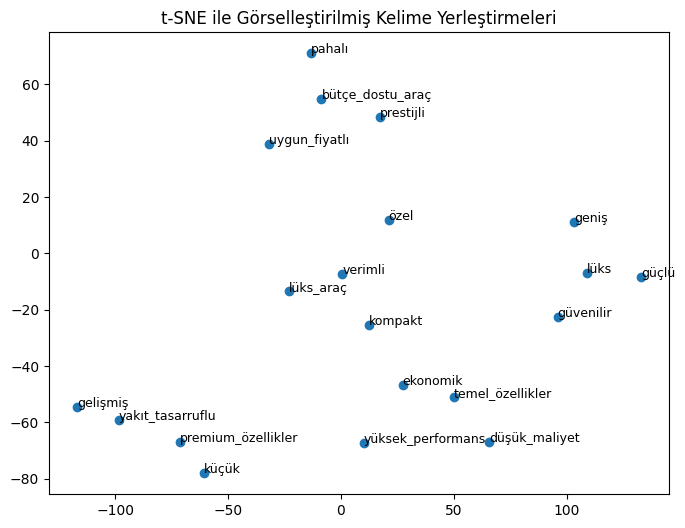

In [34]:
# t-SNE sonuçlarını çizdirme
plt.figure(figsize=(8, 6))
plt.scatter(sonuc_tsne[:, 0], sonuc_tsne[:, 1], marker='o')

for i, kelime in enumerate(yeni_kelimeler):
    plt.annotate(kelime, xy=(sonuc_tsne[i, 0], sonuc_tsne[i, 1]), fontsize=9)

plt.title("t-SNE ile Görselleştirilmiş Kelime Yerleştirmeleri")
plt.show()